# Imports

In [1]:
from tamalero.FIFO import FIFO
from tamalero.ETROC import ETROC
from tamalero.LPGBT import LPGBT
from tamalero.utils import get_kcu
from tamalero.DataFrame import DataFrame
from tamalero.colors import green, red, yellow
from tamalero.ReadoutBoard import ReadoutBoard
from tamalero.KCU import KCU
import os
import sys
import tty
import time
import select
import pickle
import termios
import struct
import numpy as np
from pathlib import Path
from tqdm import tqdm
from random import randint
from datetime import datetime, timezone,timedelta
### Custom function
from etroc_utils import convert_dict_to_pandas, save_baselines

# Definitions

In [ ]:
KCU_IP = "192.168.0.10" 

READOUTBOARD_ID = 0
READOUTBOARD_CONFIG = 'default'

ETROC_I2C_ADDRESSES = [0x60, 0x61, 0x62, 0x63]
# ETROC_NAMES = ['ET2p01_PT_LF8', 'ET2p01_PT_LF6', 'ET2p02_PT_IH8', 'ET2p02_PT_IH6']
# ETROC_NAMES = ['ET2p02_PT_IH14', 'ET2p02_PT_IH15', 'ET2p02_PT_IH8', 'ET2p02_PT_IH6'] #hpkstack
# ETROC_NAMES = ['ET2p02_PT_IH14', 'ET2p02_PT_IH15', 'ET2p02_PT_IH6', 'ET2p02_PT_IH8'] #hpkstack Ted
ETROC_NAMES = ['ET2p02_PT_IH16', 'ET2p02_PT_IH15', 'ET2p02_PT_IH6', 'ET2p02_PT_IH8'] #hpkstack Ted
# ETROC_NAMES = ['ET2p01_PT_LF4', 'ET2p01_PT_LF3', 'ET2p01_PT_LF9', 'ET2p01_PT_LF7']
# ETROC_NAMES = ['ET2p01_PT_LF6', 'ET2p01_PT_LF3', 'ET2p01_PT_LF9'] #lftstack

# ETROC_I2C_ADDRESSES = [0x60, 0x61, 0x62]
# ETROC_NAMES = ['1','2','3']

ETROC_I2C_CHANNEL = 1
ETROC_ELINKS_MAP = {0: [0, 4, 8, 12]}
# ETROC_ELINKS_MAP = {0: [0, 4, 8]}

# Test parameters
POWER_MODE = 'high'
TH_OFFSET = 20              # Threshold offset above baseline
TRIGGER_ENABLE_MASK = 0x1
TRIGGER_DATA_SIZE = 1
TRIGGER_DELAY_SEL = 468

CHARGE_FC = 30 
QINJ_COUNT = 10
CHUNK_SIZE = 500     # number of events for each saved file
running_time = 2       # minutes, None means no limit

PIXEL_ROW = 16
PIXEL_COL = 16
TEST_PIXEL_ROW = 1
TEST_PIXEL_COL = 2
NUM_ETROC = len(ETROC_I2C_ADDRESSES)

stop_acquisition = False
hit_counter = 0

### Variables for plot
path_to_figure = '/home/daq/ETROC2_KCU105/ETROC-figures'
path_to_hist = '/home/daq/ETROC2_KCU105/ETROC-History'
custom_note = ''

OUTPUT_DIR = '/home/daq/ETROC2_KCU105/ETROC-Data-CE/CC_test_qinj'

custom_note = '5c_QInj_hv180'
BLNW_FILENAME = f'HPKSTACKFINAL_{custom_note}'

# KCU and RB Init

In [ ]:
"""Initialize KCU connection"""
print('ETROC COSMIC RUN TEST - HARDWARE INITIALIZATION')
ipb_path = f"chtcp-2.0://localhost:10203?target={KCU_IP}:50001"
generic_xml_path = os.path.expandvars("$TAMALERO_BASE/address_table/generic/etl_test_fw.xml")
kcu = KCU(
    name="kcu",
    ipb_path=ipb_path,
    adr_table=generic_xml_path
)
print(green("Successfully connected to KCU."))
kcu.status()
loopback_val = 0xABCD1234
kcu.write_node("LOOPBACK.LOOPBACK", loopback_val) #
read_val = kcu.read_node("LOOPBACK.LOOPBACK").value()
if read_val == loopback_val:
    print(green(f"KCU Loopback test PASSED: Wrote 0x{loopback_val:X}, Read 0x{read_val:X}"))
else:
    print(red(f"KCU Loopback test FAILED: Wrote 0x{loopback_val:X}, Read 0x{read_val:X}"))

ETROC COSMIC RUN TEST - HARDWARE INITIALIZATION
Successfully connected to KCU.
LPGBT Link Status from KCU:
0x2021  r       READOUT_BOARD_0.LPGBT.DOWNLINK.READY              0x00000001
0x2001  r       READOUT_BOARD_0.LPGBT.UPLINK_0.READY              0x00000000
0x2001  r       READOUT_BOARD_0.LPGBT.UPLINK_0.FEC_ERR_CNT        0x00000327
0x1008  r       FW_INFO.CLK320_FREQ                               0x131CA019
0x1009  r       FW_INFO.REFCLK_FREQ                               0x131CA019
0x1018  r       FW_INFO.RXCLK0_FREQ                               0x12886B79
0x100E  r       FW_INFO.TXCLK0_FREQ                               0x131CA019
0x100F  r       FW_INFO.TXCLK1_FREQ                               0x131CA019
KCU Loopback test PASSED: Wrote 0xABCD1234, Read 0xABCD1234


In [4]:
"""Initialize readout board"""
rb = ReadoutBoard(
    rb=READOUTBOARD_ID,
    kcu=kcu,
    config=READOUTBOARD_CONFIG, 
    trigger=False,     
    verbose=False
)
print(green(f"Readout Board version detected: {rb.ver}"))

0x1d7 readback value is 0x30
lpGBT version found False
1
0x1d7 readback value is 0xae
lpGBT version found True
 > lpGBT v2 detected
100khz
 > Running power up within LPGBT.configure()
 > VTRx+ version detected: production
100khz
Readout Board version detected: 2


In [ ]:
print("Checking DAQ LpGBT base configuration:")
print("\nReading temperatures:")
rb.read_temp(verbose=True) #
print("\nReading DAQ LpGBT ADCs:")
try:
    rb.DAQ_LPGBT.read_adcs(check=True, strict_limits=True) #
except ValueError as e:
    print(f"LpGBT ADC check issue: {e}")
print(f"\nDAQ LpGBT Link Good: {rb.DAQ_LPGBT.link_status()}") 
fec_errors = rb.get_FEC_error_count() # Reads KCU registers defined in READOUT_BOARD.xml
print(f"FEC Errors: DAQ LpGBT = {fec_errors.get('DAQ', 'N/A')}")

Checking DAQ LpGBT base configuration:

Reading temperatures:

Temperature on RB RT1 is: 19.3 C
Temperature on RB RT2 is: 25.6 C

 ETROC Internal Temp
VTEMP1: 1.2 C
VTEMP2: 6.0 C
VTEMP3: 1.4 C
VTEMP4: 4.1 C

Reading DAQ LpGBT ADCs:
┌─────────────────┬───────┬─────────────────┬───────────────────┬────────────────────┬──────────────────┬─────────────────────┬──────────┬──────────────────────────────────────────────────────┐
│ Register        │ Pin   │   Reading (raw) │   Reading (calib) │   Voltage (direct) │   Voltage (conv) │   current_value (A) │ Status   │ Comment                                              │
├─────────────────┼───────┼─────────────────┼───────────────────┼────────────────────┼──────────────────┼─────────────────────┼──────────┼──────────────────────────────────────────────────────┤
│ Vref1m          │ 2     │             822 │           815.016 │           0.796692 │         0.993475 │                     │ OK       │ Vref from ETROC B1 (B2)                        

# ETROC Init and Set High Power

In [6]:
"""Initialize all ETROC chips"""
print("\n3. Initializing ETROC chips...")
etroc_chips = []

for i, addr in enumerate(ETROC_I2C_ADDRESSES):
    chip_name = ETROC_NAMES[i]
    
    print(f"\nInitializing {chip_name} (I2C: 0x{addr:02X})...")
    
    try:
        etroc = ETROC(
            rb,
            master='lpgbt',
            i2c_adr=addr,
            i2c_channel=ETROC_I2C_CHANNEL,
            elinks=ETROC_ELINKS_MAP,
            strict=False,
            verbose=False
        )
        etroc_chips.append(etroc)
        
        # Verify communication
        if etroc.is_connected():
            # Check key registers
            scrambler_status = etroc.rd_reg("disScrambler")
            controller_state = etroc.rd_reg("controllerState")
            pll_unlock_count = etroc.rd_reg("pllUnlockCount")
            
            print(green(f"✓ {chip_name} connected successfully"))
            print(f"  Controller state: {controller_state} (should be 11)")
            print(f"  PLL unlock count: {pll_unlock_count}")
            
            if scrambler_status == 1:
                print(green("  Register communication verified"))
            else:
                print(red("   Register communication issue"))
        else:
            print(red(f"✗ {chip_name} not responding"))
            
    except Exception as e:
        print(red(f"Failed to initialize {chip_name}: {e}"))
        etroc_chips.append(None)

print(green("\n Hardware initialization completed successfully!"))
print(f"Initialized {len([c for c in etroc_chips if c is not None])} ETROC chips")
print("\nETROC to E-link Mapping:")
elink_list = ETROC_ELINKS_MAP[0]  # [0, 4, 8, 12]
for i, (addr, elink) in enumerate(zip(ETROC_I2C_ADDRESSES, elink_list)):
    chip_name = f"Chip{i+1}"
    if i < len(etroc_chips) and etroc_chips[i] is not None:
        status = "Connected"
    else:
        status = "Failed"
    print(f"  {chip_name} (I2C: 0x{addr:02X}) <-> E-link {elink} - {status}")


3. Initializing ETROC chips...

Initializing ET2p02_PT_IH16 (I2C: 0x60)...
elinks not locked, resetting PLL and FC modules
✓ ET2p02_PT_IH16 connected successfully
  Controller state: 11 (should be 11)
  PLL unlock count: 0
  Register communication verified

Initializing ET2p02_PT_IH15 (I2C: 0x61)...
elinks not locked, resetting PLL and FC modules
✓ ET2p02_PT_IH15 connected successfully
  Controller state: 11 (should be 11)
  PLL unlock count: 2
  Register communication verified

Initializing ET2p02_PT_IH6 (I2C: 0x62)...
elinks not locked, resetting PLL and FC modules
✓ ET2p02_PT_IH6 connected successfully
  Controller state: 11 (should be 11)
  PLL unlock count: 3
  Register communication verified

Initializing ET2p02_PT_IH8 (I2C: 0x63)...
elinks not locked, resetting PLL and FC modules
✓ ET2p02_PT_IH8 connected successfully
  Controller state: 11 (should be 11)
  PLL unlock count: 2
  Register communication verified

 Hardware initialization completed successfully!
Initialized 4 ETRO

In [7]:
for etroc in etroc_chips:
        etroc.set_power_mode(mode=POWER_MODE, row=0, col=0, broadcast=True)
for etroc in etroc_chips:
        if(etroc.get_power_mode(row=8, col=8)!=POWER_MODE):
                print(red("Power Mode Error"))

# Calibrate and Save BL/NW

In [8]:
"""Calibrate baseline for all pixels"""
print(f"\n2. Calibrating {PIXEL_ROW * PIXEL_COL} pixel baselines...")

baseline_storage = {}
baseline_dict = {}
nw_dict = {}
chip_names = ETROC_NAMES
etroc_configs = []
failed_pixels = {}

def save_to_pickle(file_name):
    data_to_save = {
    'baseline': baseline_dict,
    'NW' : nw_dict,
    'chip_name':chip_names
    }
    with open(f'{file_name}.pkl', 'wb') as f:
        pickle.dump(data_to_save,f)
    print('Data saved')
def load_from_pickle(file_name):
    with open(f'{file_name}.pkl', 'rb') as f:
        loaded_data = pickle.load(f)
    print('Data Loaded')
    return loaded_data

print("\n3. Generating test pixel configuration...")
all_pixels_per_chip = []
for _ in range(NUM_ETROC):
    chip_pixels = []
    for row in range(PIXEL_ROW):
        for col in range(PIXEL_COL):
            chip_pixels.append((row, col))
    all_pixels_per_chip.append(chip_pixels)

for i, (etroc, chip_name) in enumerate(zip(etroc_chips, ETROC_NAMES)):
    if etroc is not None and i < len(all_pixels_per_chip):
        etroc_configs.append((etroc, chip_name, all_pixels_per_chip[i]))

print("Test pixel assignments:")
for etroc, chip_name, pixels in etroc_configs:
    print(f"  {chip_name}: {len(pixels)} pixels")

for etroc, chip_name, test_pixels in etroc_configs:
    baseline_dict[chip_name] = {}
    nw_dict[chip_name] = {}
    baseline_storage[chip_name] = {
            'row': [], 'col': [], 'baseline': [],
            'noise_width': [], 'timestamp': []
        }
    failed_pixels[chip_name] = []
    print(f"\nScanning {chip_name}...")
    
    for pixel_row, pixel_col in tqdm(test_pixels, desc = f"{chip_name} pixels"):
        baseline_storage[chip_name]['row'].append(pixel_row)
        baseline_storage[chip_name]['col'].append(pixel_col)
        try:
            baseline, noise_width = etroc.auto_threshold_scan(
                row=pixel_row,
                col=pixel_col,
                broadcast=False,
                offset=1023,
                use=False,
                verbose=True
            )
            baseline_dict[chip_name][(pixel_row, pixel_col)] = baseline
            nw_dict[chip_name][(pixel_row, pixel_col)] = noise_width
            baseline_storage[chip_name]['baseline'].append(baseline)
            baseline_storage[chip_name]['noise_width'].append(noise_width)
        except Exception as e:
            print(red(f"  Pixel ({pixel_row},{pixel_col}): SCAN FAILED - {e}"))
            failed_pixels[chip_name].append((pixel_row, pixel_col))
            baseline_dict[chip_name][(pixel_row, pixel_col)] = 0
            nw_dict[chip_name][(pixel_row, pixel_col)] = 0
            baseline_storage[chip_name]['baseline'].append(0)
            baseline_storage[chip_name]['noise_width'].append(0)
        # 4. Append data for EVERY pixel (values are None on failure)
        baseline_storage[chip_name]['timestamp'].append(datetime.now().isoformat(sep=' '))

    if failed_pixels[chip_name]:
        print(red(f"  Found {len(failed_pixels[chip_name])} pixels with scan failures during sampling"))
save_to_pickle(file_name=BLNW_FILENAME)

# Print summary of baseline calibration
total_failed_pixels = sum(len(failed_list) for failed_list in failed_pixels.values())
print(green("Baseline calibration completed"))

if total_failed_pixels > 0:
    print(yellow(f"WARNING: Found {total_failed_pixels} pixels with baseline scan failures:"))
    for chip_name, failed_list in failed_pixels.items():
        if failed_list:
            print(f"  {chip_name}: {failed_list}")
else:
    print(green("All pixels passed baseline scan"))
time.sleep(1)


2. Calibrating 256 pixel baselines...

3. Generating test pixel configuration...
Test pixel assignments:
  ET2p02_PT_IH16: 256 pixels
  ET2p02_PT_IH15: 256 pixels
  ET2p02_PT_IH6: 256 pixels
  ET2p02_PT_IH8: 256 pixels

Scanning ET2p02_PT_IH16...


ET2p02_PT_IH16 pixels: 100%|██████████| 256/256 [00:28<00:00,  9.13it/s]



Scanning ET2p02_PT_IH15...


ET2p02_PT_IH15 pixels: 100%|██████████| 256/256 [00:28<00:00,  8.99it/s]



Scanning ET2p02_PT_IH6...


ET2p02_PT_IH6 pixels: 100%|██████████| 256/256 [00:28<00:00,  9.07it/s]



Scanning ET2p02_PT_IH8...


ET2p02_PT_IH8 pixels: 100%|██████████| 256/256 [00:26<00:00,  9.70it/s]


Data saved
Baseline calibration completed
All pixels passed baseline scan


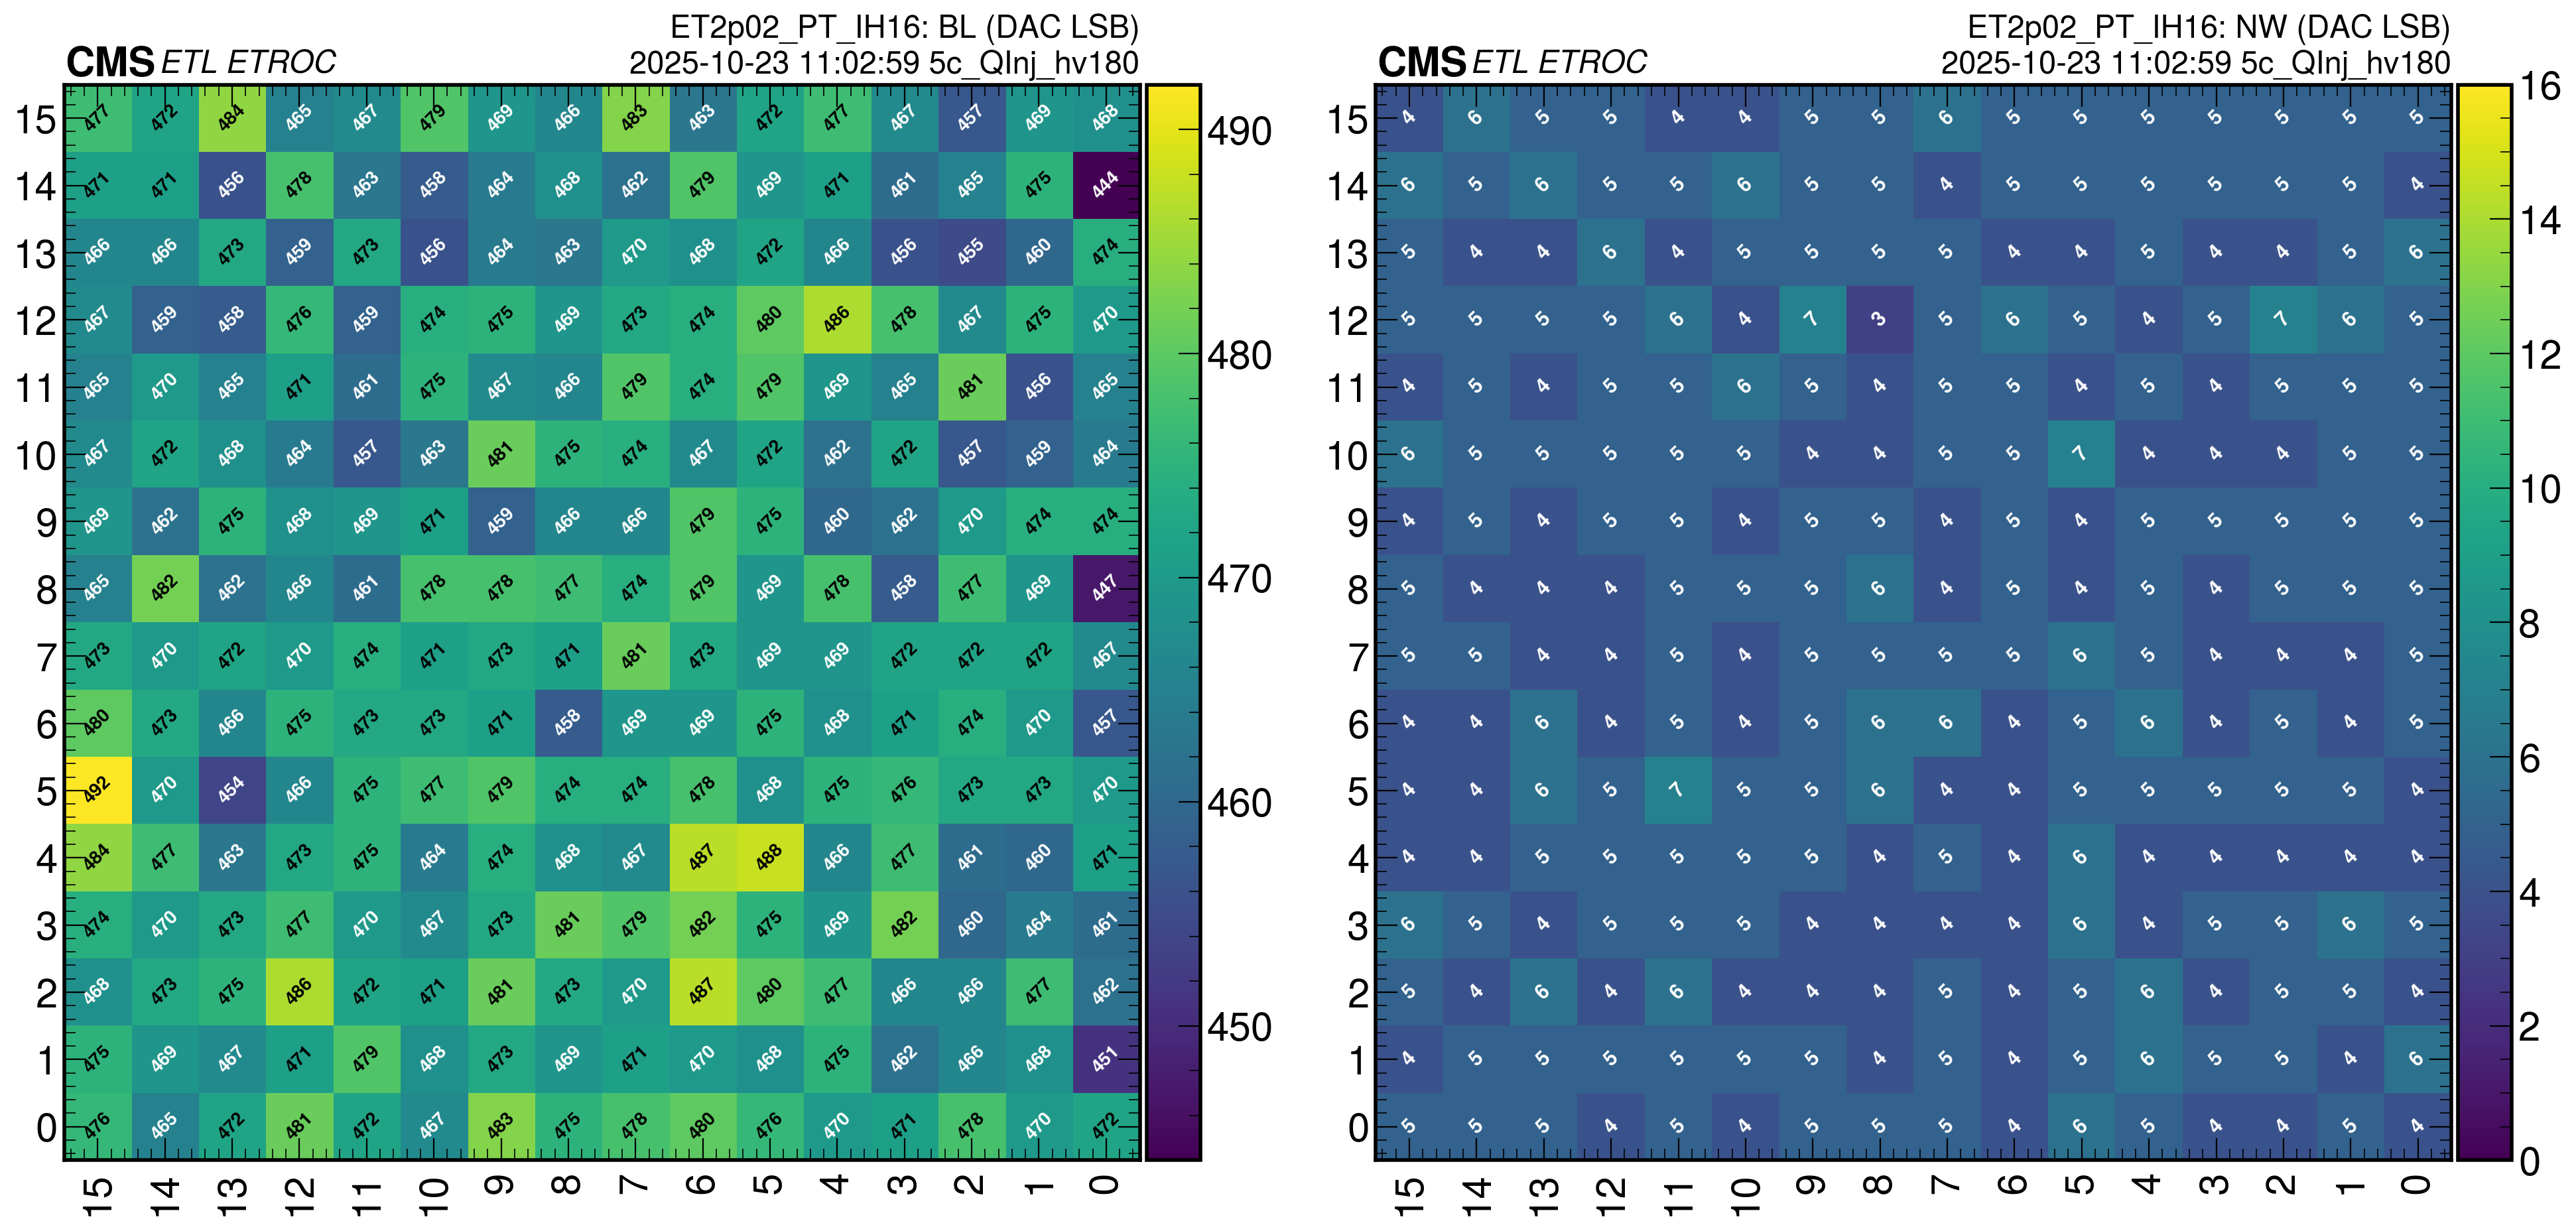

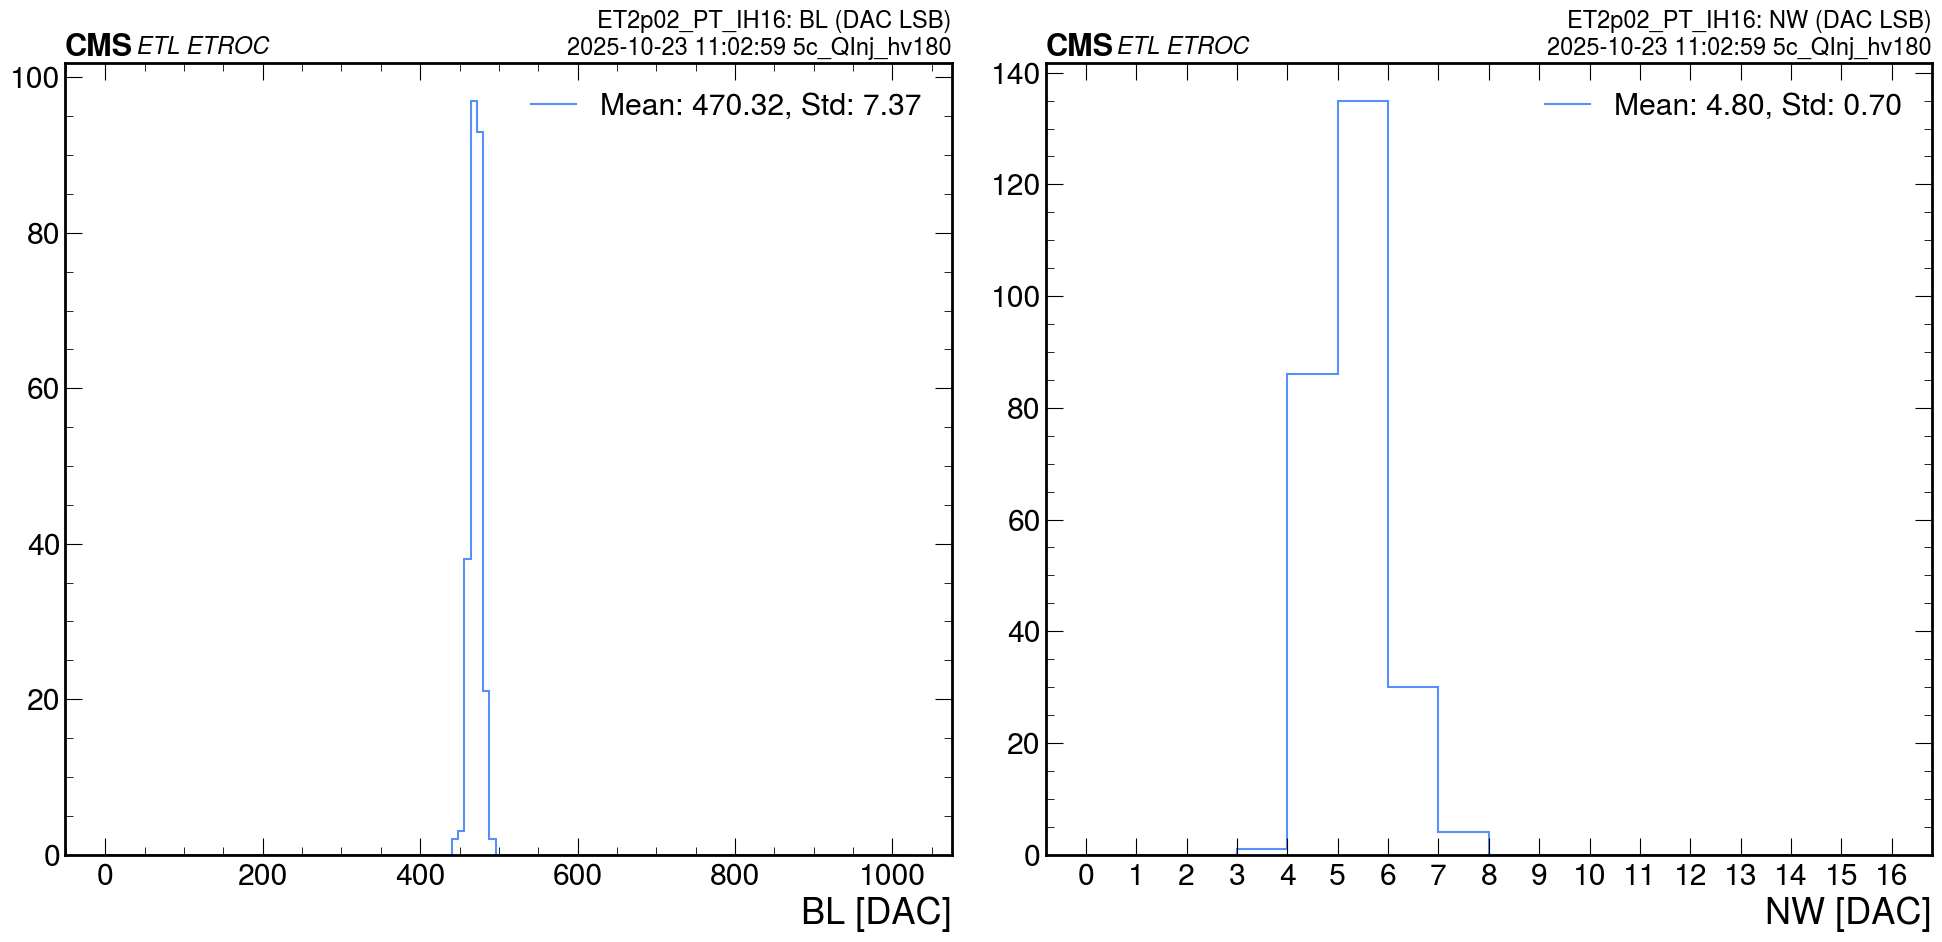

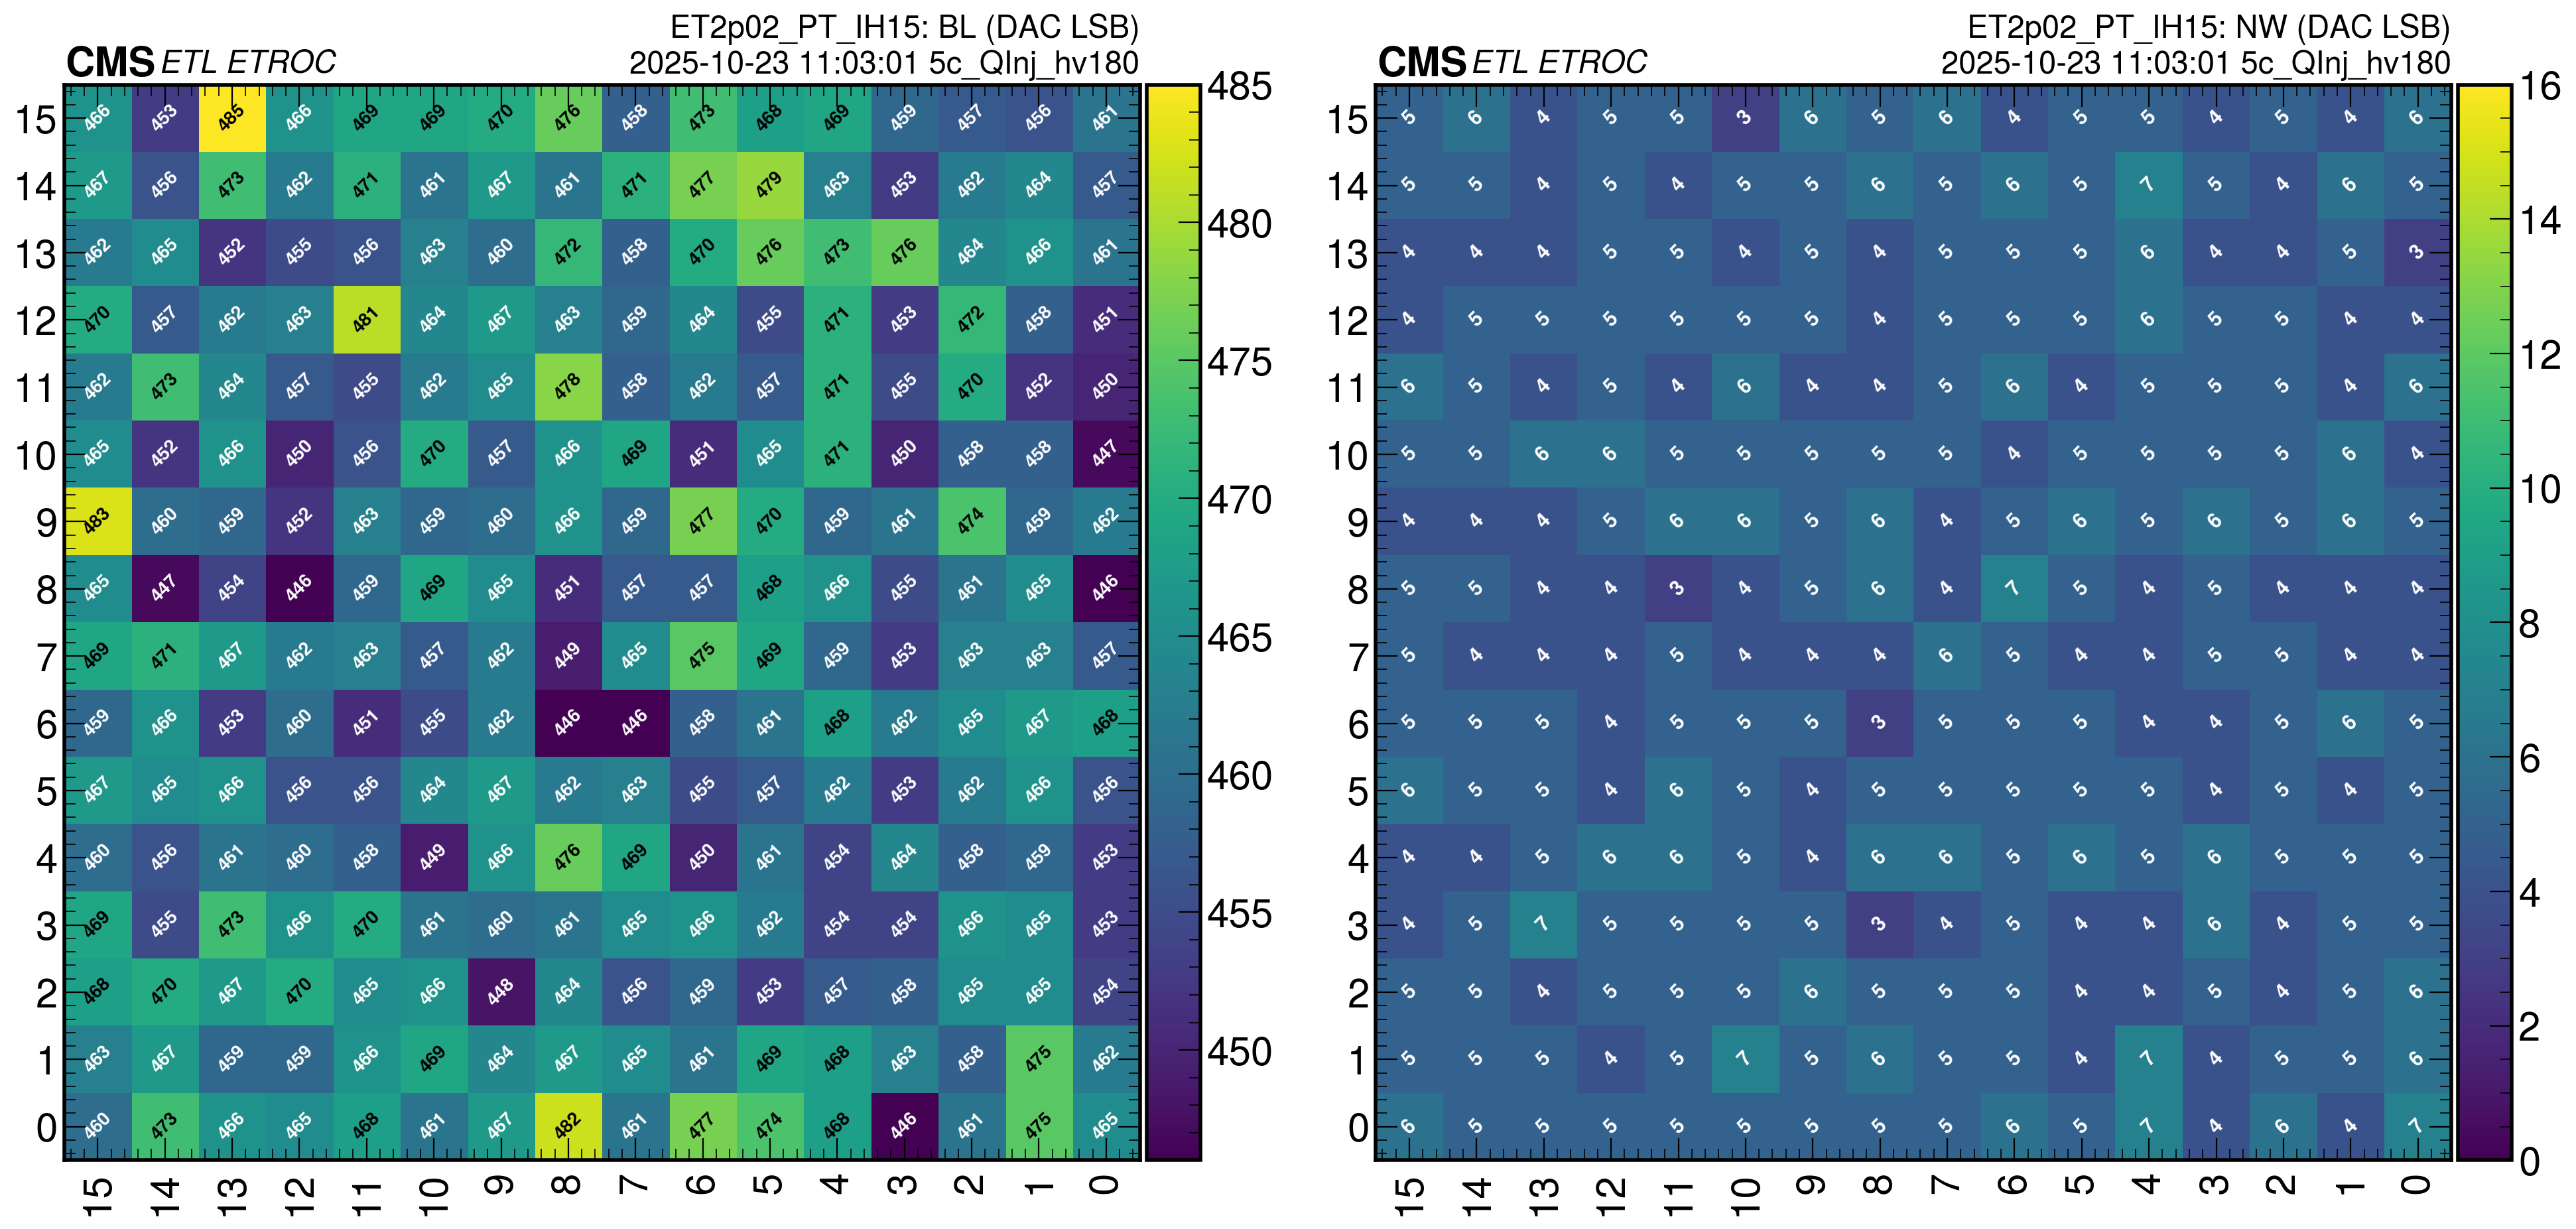

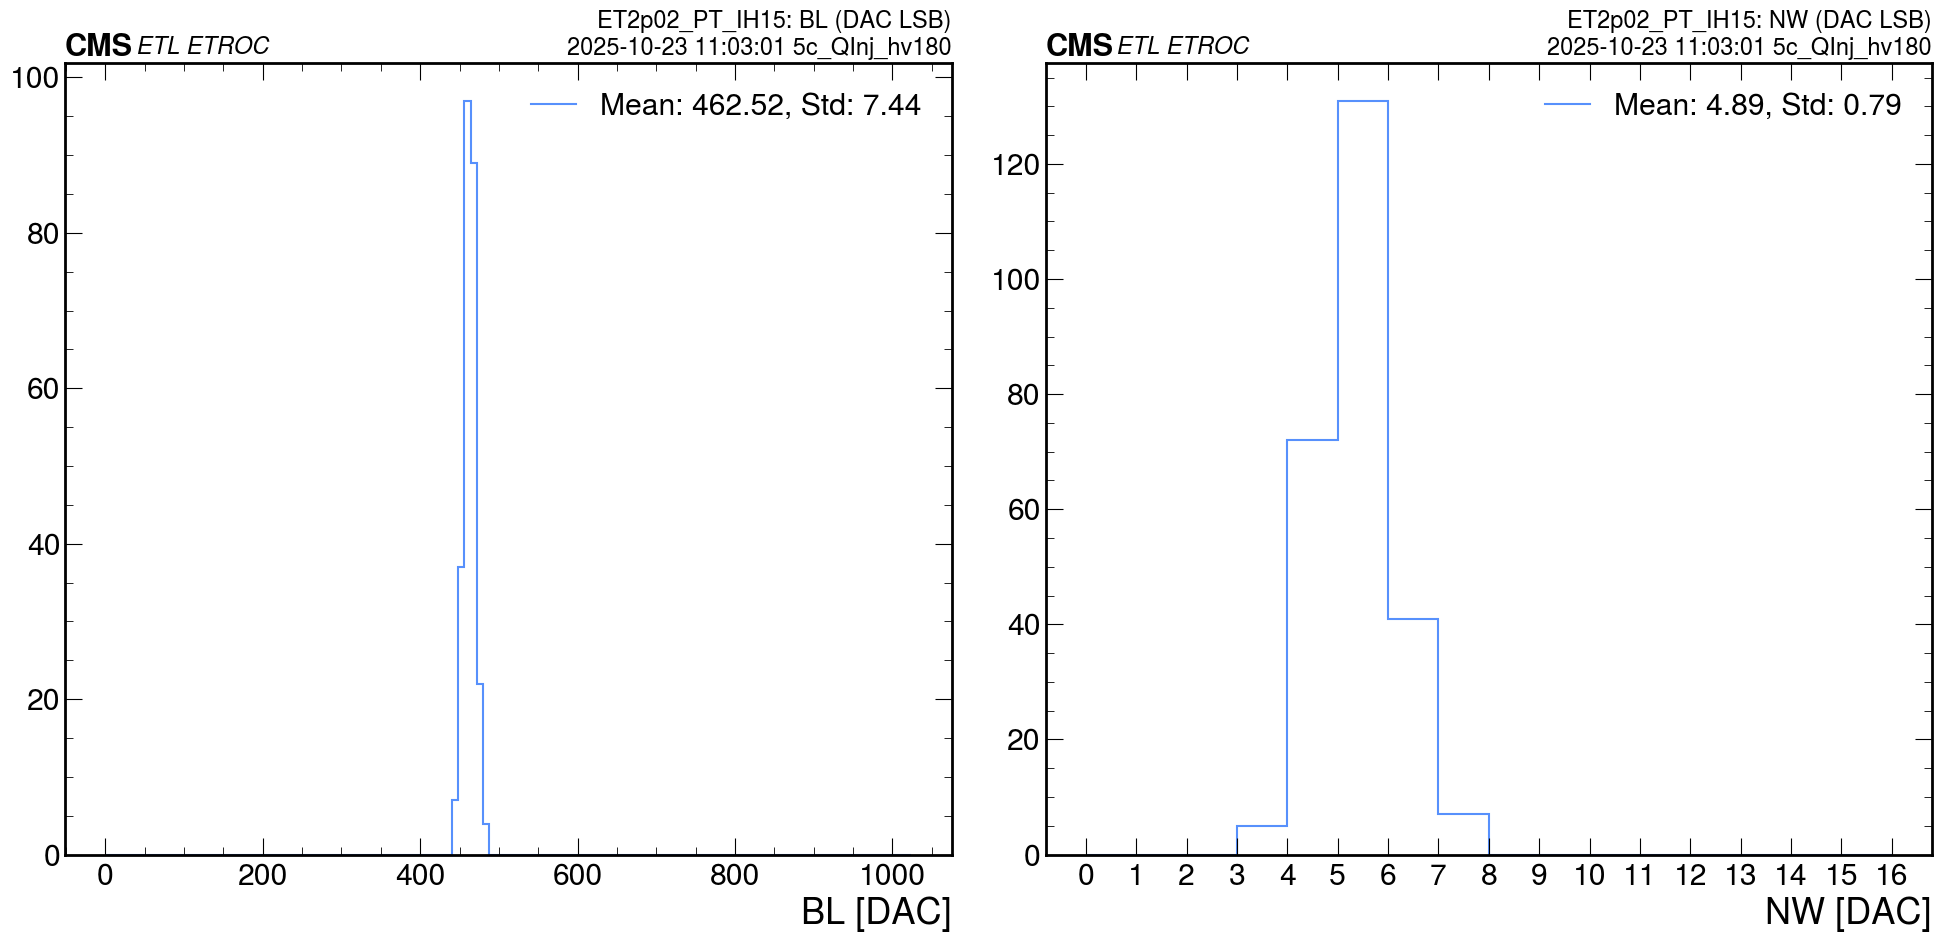

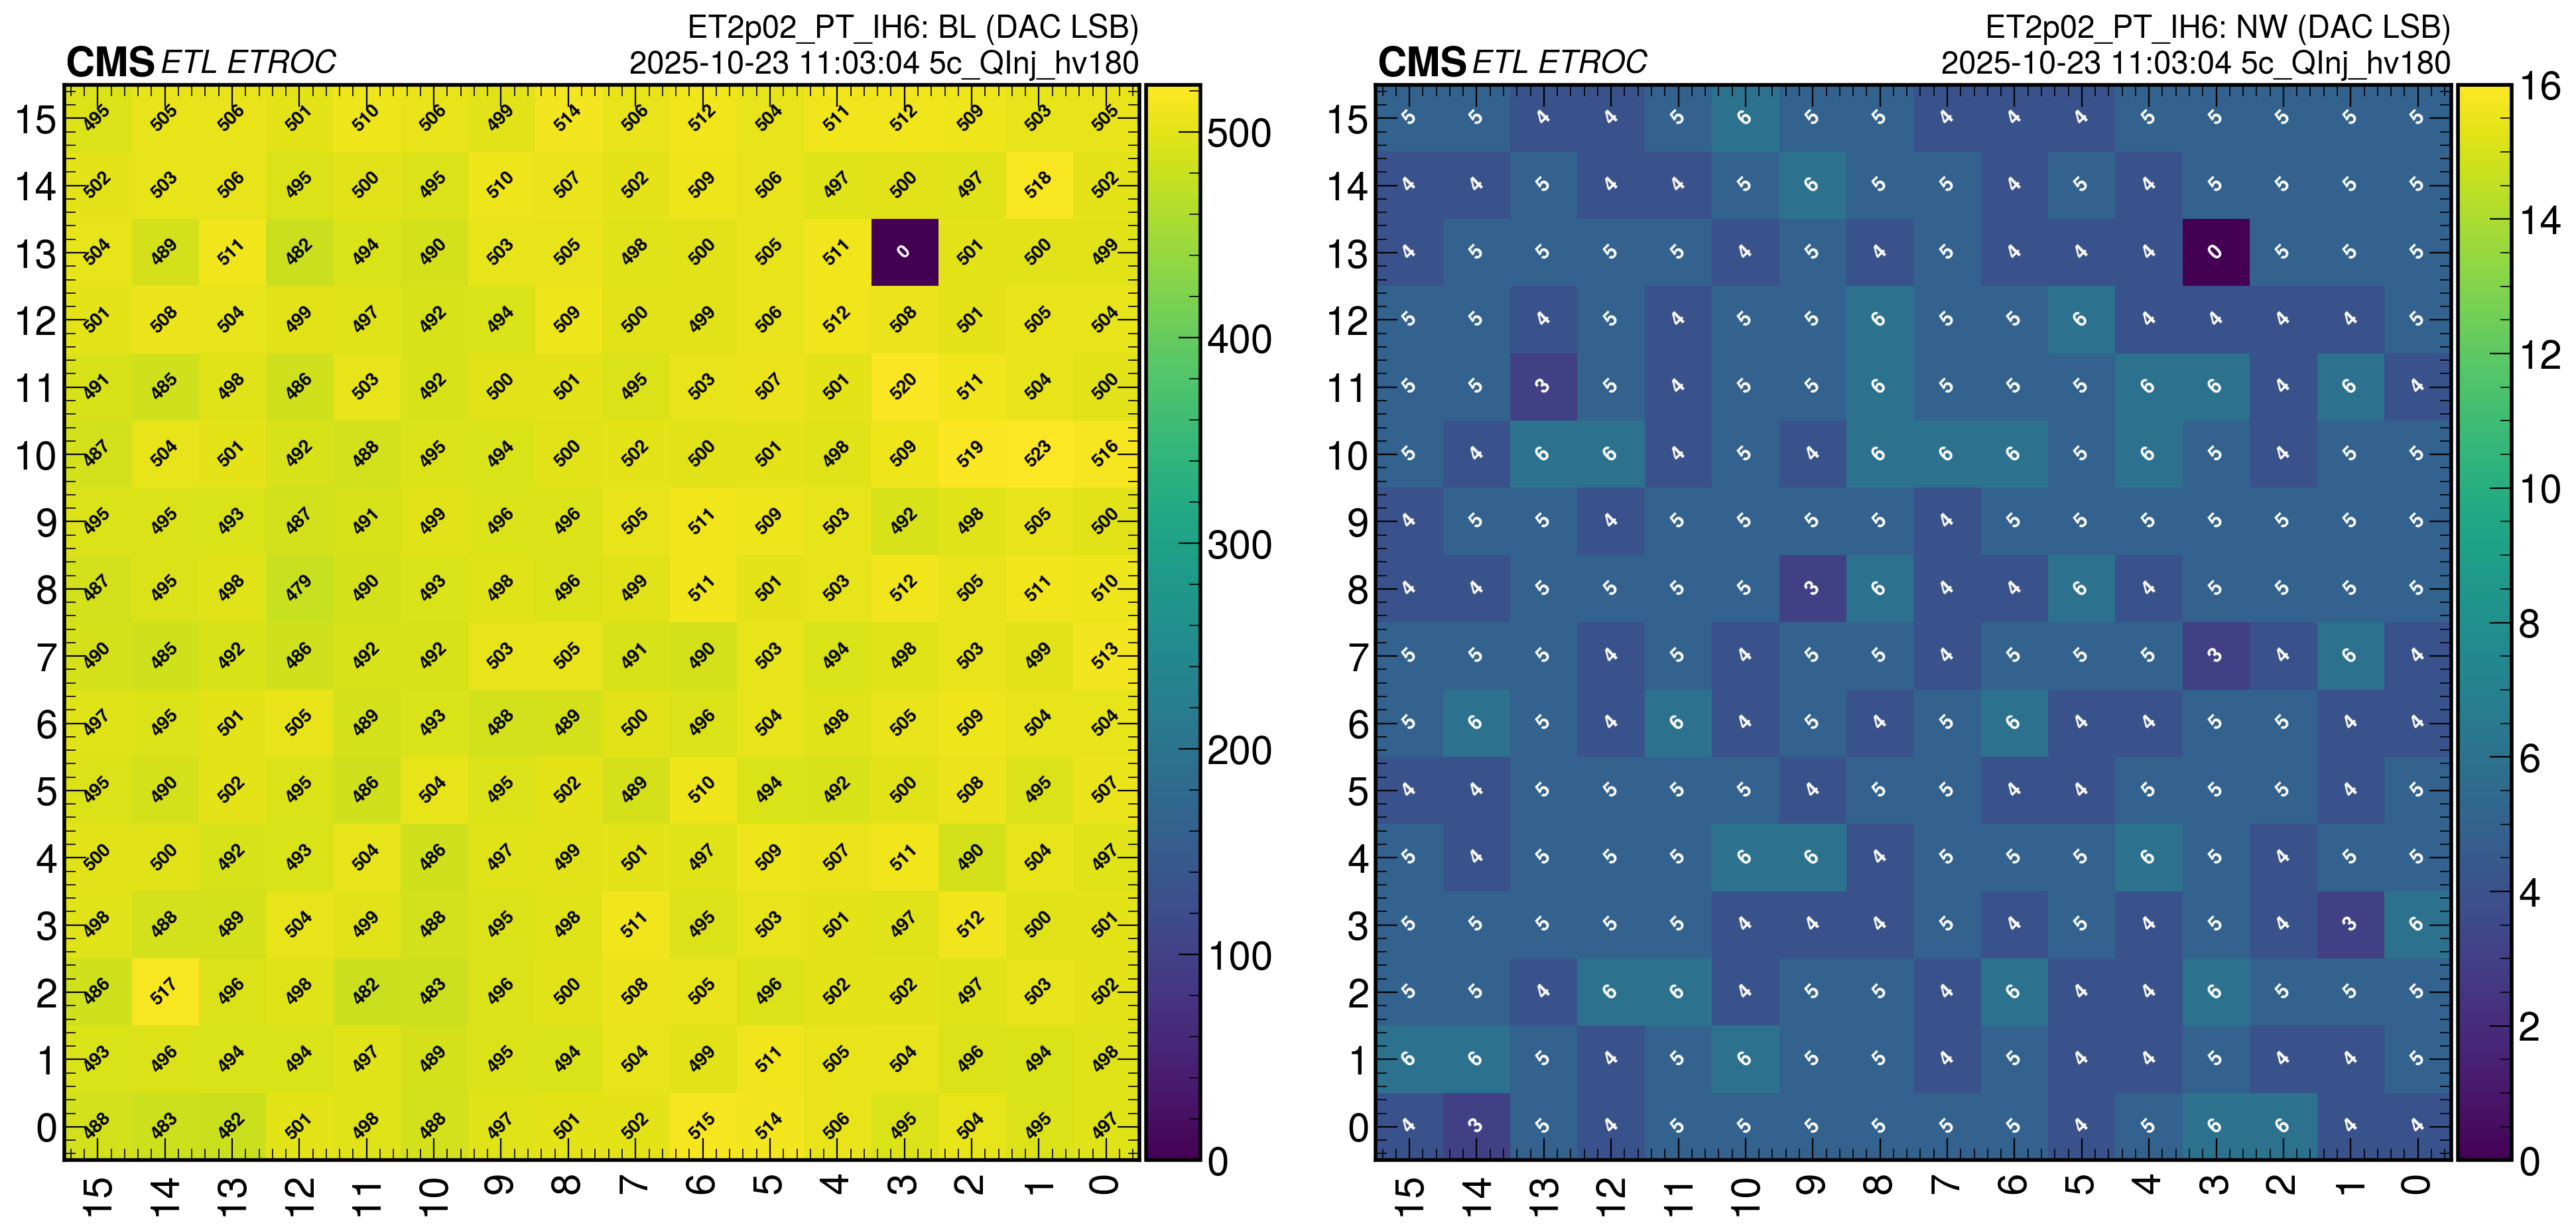

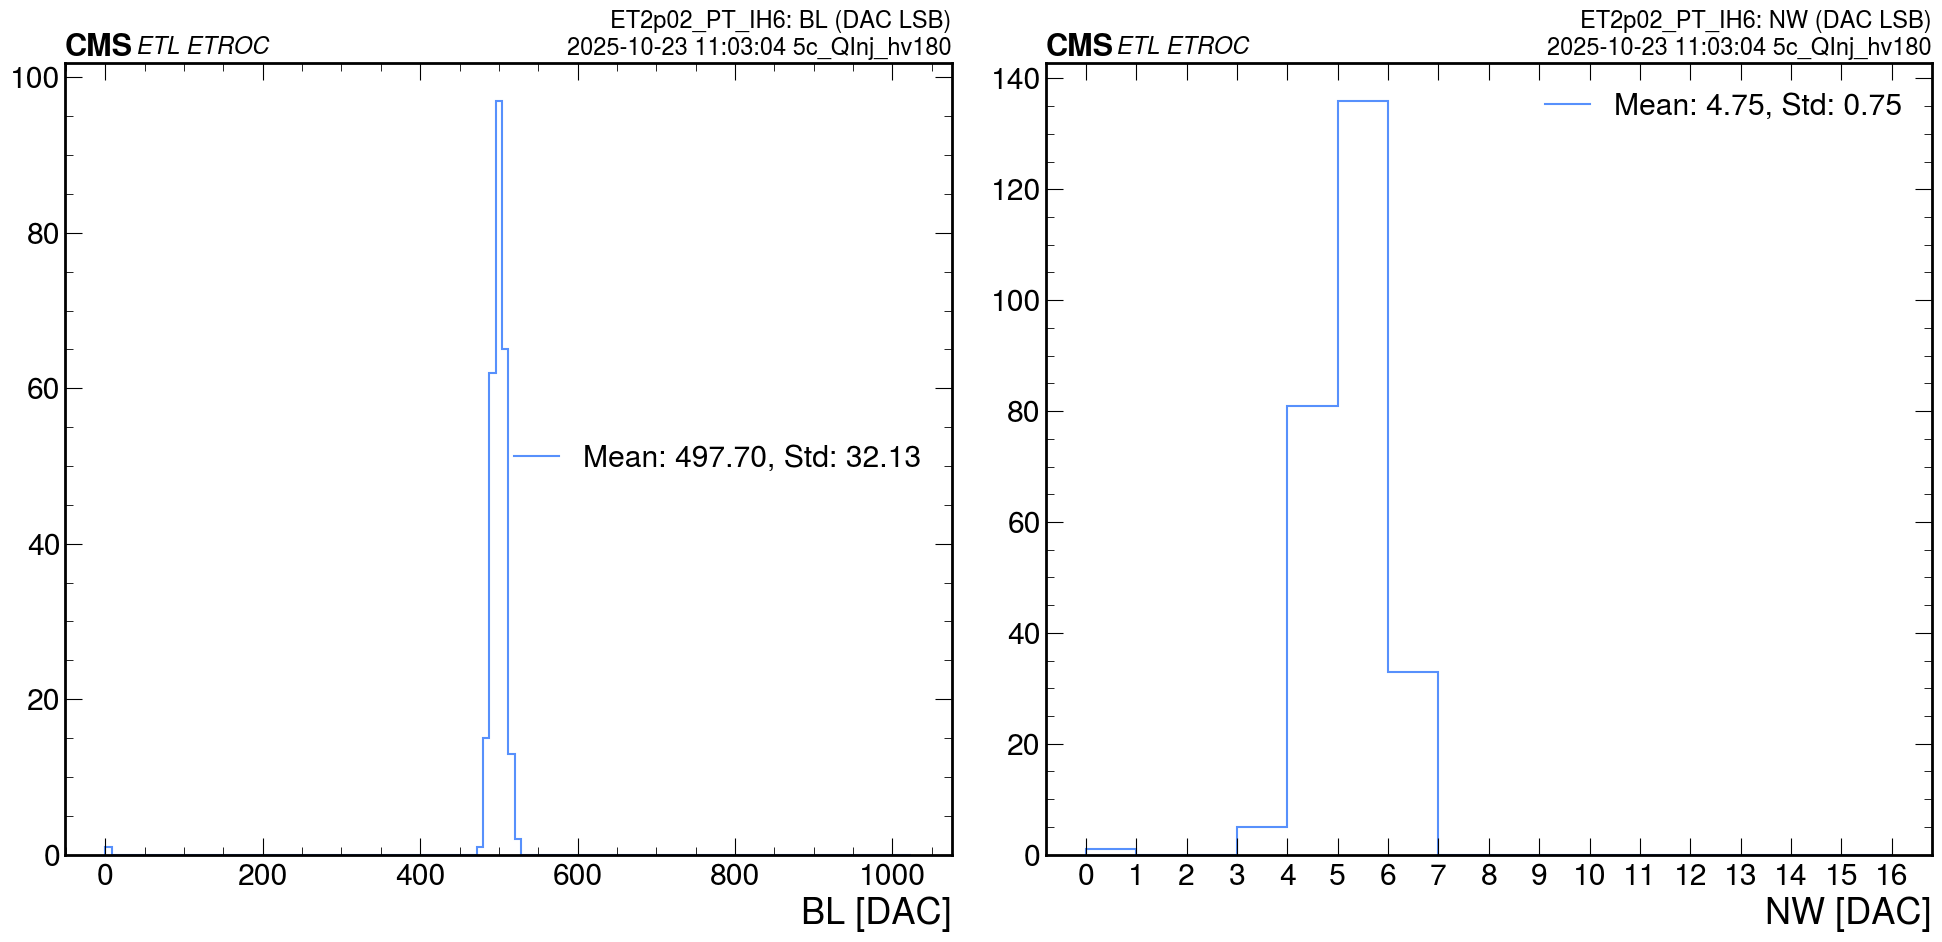

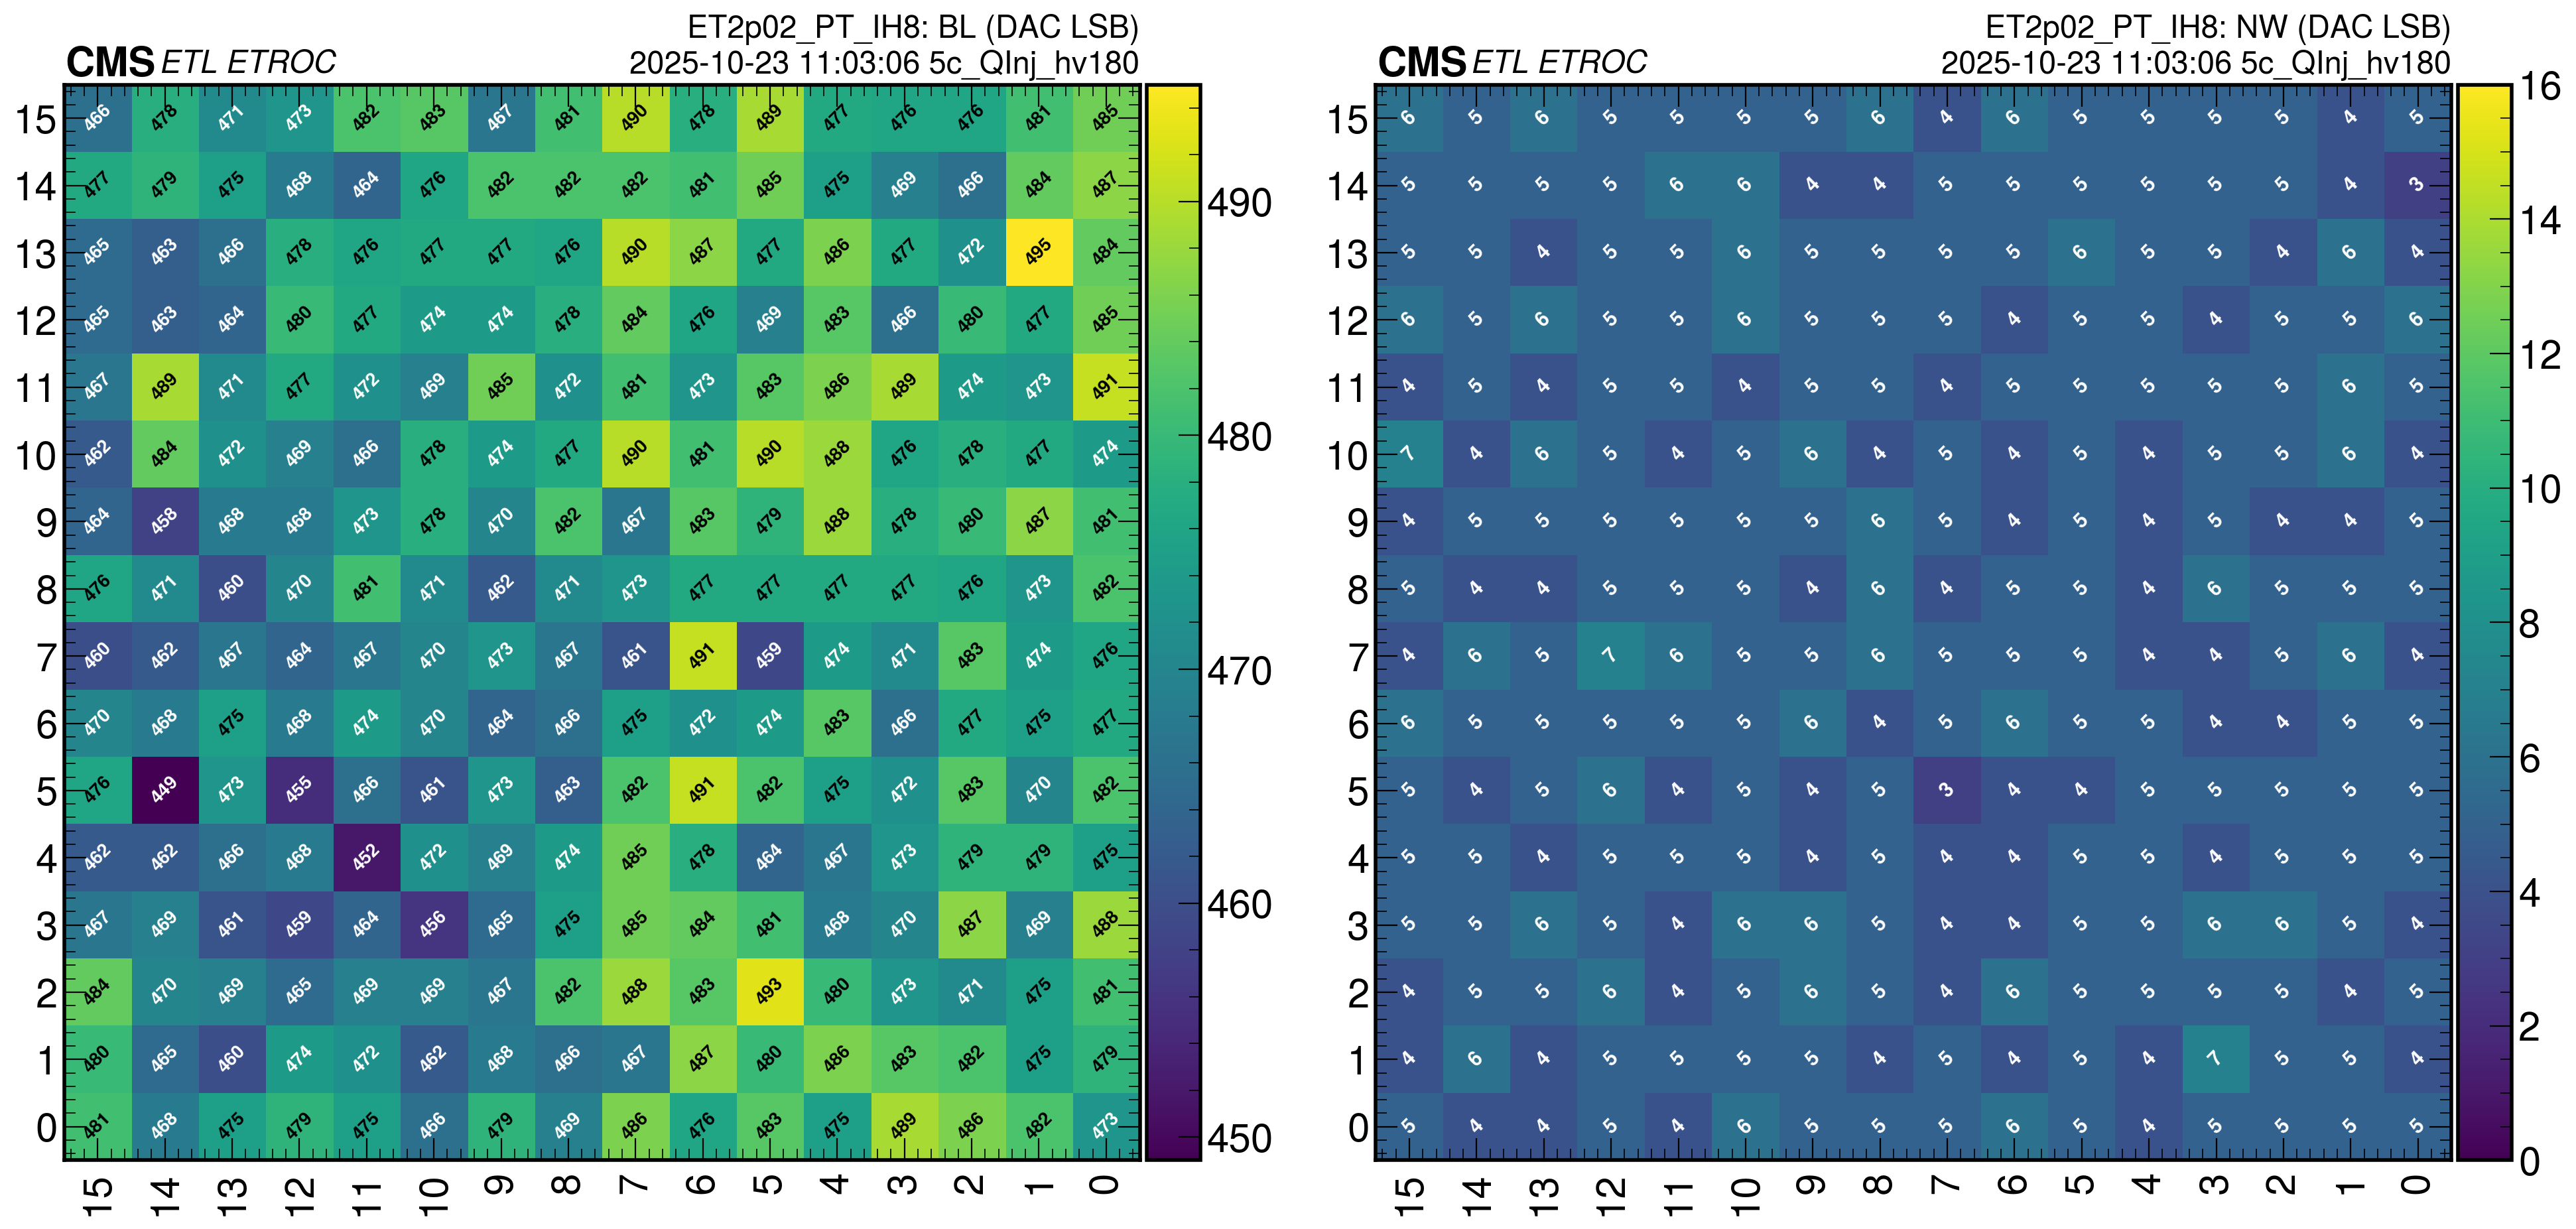

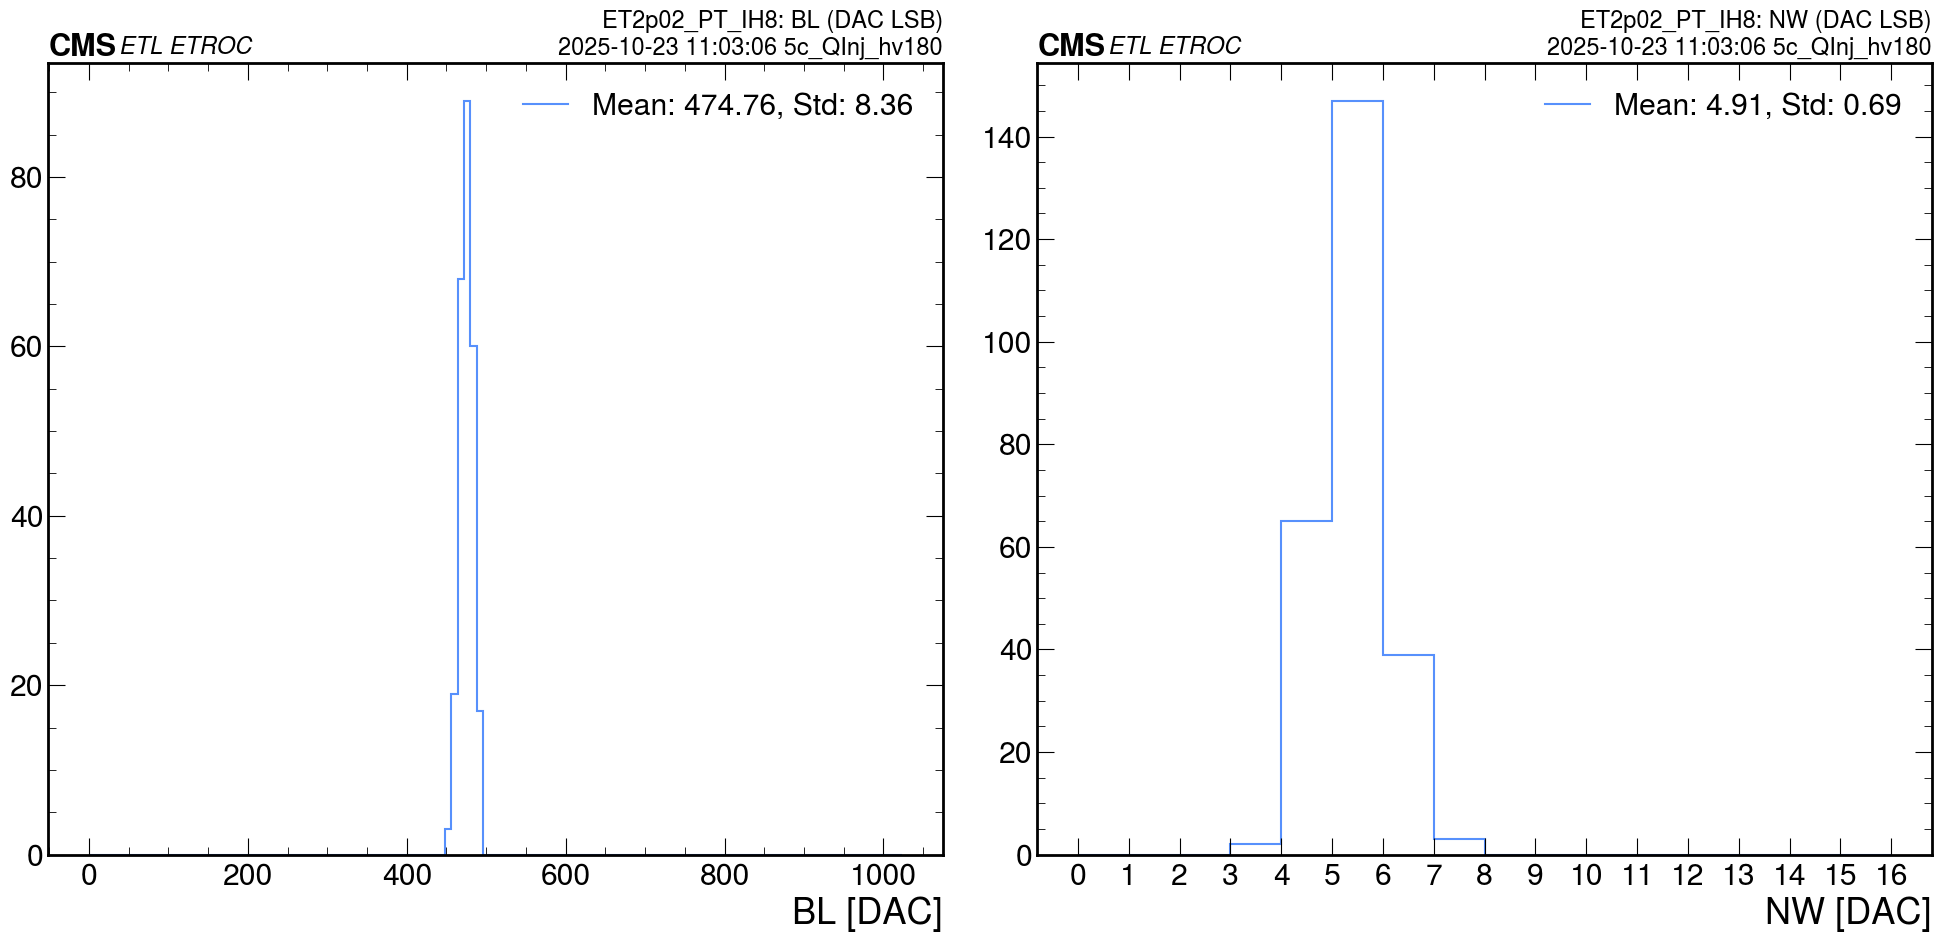

In [9]:
for key, val in baseline_storage.items():
    bl_nw_df = convert_dict_to_pandas(val, key)
    tmp_timestamp = datetime.now().isoformat(sep=' ', timespec='seconds')
    my_note = tmp_timestamp + ' ' + custom_note
    save_baselines(bl_nw_df, key,
                    hist_dir=path_to_hist,
                    fig_dir=path_to_figure,
                    save_notes=my_note)   

# Configure Chips for QInj

In [10]:
# custom_note = 'RT_hv200'
# BLNW_FILENAME = f'HPKSTACKFINAL_{custom_note}'

"""Configure all ETROC chips for cosmic run detection"""
print(f"\n4. Configuring all {TEST_PIXEL_ROW * TEST_PIXEL_COL} pixels for cosmic run detection...")

loaded_data = load_from_pickle(file_name=BLNW_FILENAME)
baseline_dict = loaded_data['baseline']
nw_dict = loaded_data['NW']
chip_names = loaded_data['chip_name']

# Make reduced etroc config
etroc_configs = []
print("\n3. Generating test pixel configuration...")
test_pixels_per_chip = []
for _ in range(NUM_ETROC):
    chip_pixels = []
    for row in range(TEST_PIXEL_ROW):
        for col in range(TEST_PIXEL_COL):
            chip_pixels.append((row, col))
    test_pixels_per_chip.append(chip_pixels)
for i, (etroc, chip_name) in enumerate(zip(etroc_chips, ETROC_NAMES)):
    if etroc is not None and i < len(test_pixels_per_chip):
        etroc_configs.append((etroc, chip_name, test_pixels_per_chip[i]))

# Reset and configure all chips
for _, (etroc, chip_name, all_pixels) in enumerate(etroc_configs):
    print(f"Configuring {chip_name} - pixels)...")
    etroc.reset()
    time.sleep(0.1)
    etroc.wr_reg("singlePort", 1)
    # Disable all pixels initially
    etroc.wr_reg("disDataReadout", 1, broadcast=True)
    etroc.wr_reg("QInjEn", 0, broadcast=True) 
    etroc.wr_reg("enable_TDC", 0, broadcast=True)
    etroc.wr_reg("disTrigPath", 1, broadcast=True)
    etroc.wr_reg("workMode", 0, broadcast=True)
    etroc.wr_reg('triggerGranularity', 1)
    time.sleep(0.1)
    
    # Configure all pixels for cosmic ray detection
    with tqdm(total=len(all_pixels), desc=f"{chip_name} pixels", ncols=100) as pbar:
        for pixel_row, pixel_col in all_pixels:
            # Set DAC threshold (baseline + Offset)
            etroc.wr_reg("workMode", 0, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.wr_reg("enable_TDC", 1, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.wr_reg("disDataReadout", 0, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.wr_reg("disTrigPath", 0, row=pixel_row, col=pixel_col, broadcast=False)
            # time.sleep(0.1)
            baseline = baseline_dict[chip_name][(pixel_row, pixel_col)]
            applied_dac = baseline + TH_OFFSET
            etroc.wr_reg('DAC', applied_dac, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.wr_reg("QSel", CHARGE_FC - 1, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.wr_reg("QInjEn", 1, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.set_trigger_TH('TOA', upper=0x3ff, lower=0, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.set_trigger_TH('TOT', upper=0x1ff, lower=0, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.set_trigger_TH('Cal', upper=0x3ff, lower=0, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.set_data_TH('TOA', upper=0x3ff, lower=0 ,row=pixel_row, col=pixel_col, broadcast=False)
            etroc.set_data_TH('TOT', upper=0x1ff, lower=0 ,row=pixel_row, col=pixel_col, broadcast=False)
            etroc.set_data_TH('Cal', upper=0x3ff, lower=0 ,row=pixel_row, col=pixel_col, broadcast=False)
            pbar.update(1)
            pbar.set_postfix({
                'pixel': f'({pixel_row},{pixel_col})', 
                'DAC': f'{applied_dac:.0f}'
            })
            
            # Small delay to prevent communication issues
            # if (pixel_row * 16 + pixel_col) % 32 == 0:  # Every 32 pixels
            #     time.sleep(0.01)

print(green(f"All {TEST_PIXEL_ROW * TEST_PIXEL_COL} pixel configuration completed"))


4. Configuring all 2 pixels for cosmic run detection...
Data Loaded

3. Generating test pixel configuration...
Configuring ET2p02_PT_IH16 - pixels)...


ET2p02_PT_IH16 pixels: 100%|████████████████████| 2/2 [00:00<00:00,  4.20it/s, pixel=(0,1), DAC=490]


Configuring ET2p02_PT_IH15 - pixels)...


ET2p02_PT_IH15 pixels: 100%|████████████████████| 2/2 [00:00<00:00,  5.77it/s, pixel=(0,1), DAC=495]


Configuring ET2p02_PT_IH6 - pixels)...


ET2p02_PT_IH6 pixels: 100%|█████████████████████| 2/2 [00:00<00:00,  5.85it/s, pixel=(0,1), DAC=515]


Configuring ET2p02_PT_IH8 - pixels)...


ET2p02_PT_IH8 pixels: 100%|█████████████████████| 2/2 [00:00<00:00,  5.77it/s, pixel=(0,1), DAC=502]

All 2 pixel configuration completed


# Configure Self Trigger for QInj

In [27]:
TRIGGER_DELAY_SEL = 469
"""Configure self-trigger system"""
print("\n6. Configuring self-trigger system...")

rb.kcu.write_node(f"READOUT_BOARD_{rb.rb}.TRIG_ENABLE_MASK", TRIGGER_ENABLE_MASK)
rb.kcu.write_node(f"READOUT_BOARD_{rb.rb}.TRIG_DATA_SIZE", TRIGGER_DATA_SIZE)
rb.kcu.write_node(f"READOUT_BOARD_{rb.rb}.TRIG_DLY_SEL", TRIGGER_DELAY_SEL)

print(f"Trigger ENABLE Mask: 0x{TRIGGER_ENABLE_MASK:X}")
print(f"Trigger DATA SIZE: {TRIGGER_DATA_SIZE}")
print(f"Trigger DELAY SEL: {TRIGGER_DELAY_SEL}")
time.sleep(0.1)

# check elink status
for elink in [0,4,8,12]:
    locked = rb.etroc_locked(elink, slave=False)
    print(f"elink: {elink} locked status: {locked}")
    if not locked:
        print(yellow(f"Warning: E-link {elink} is NOT locked after configuration. Attempting to re-lock..."))
        rb.rerun_bitslip() 
        time.sleep(0.5)
        locked = rb.etroc_locked(elink, slave=False) 
        print(f"After re-lock, elink {elink} locked status : {locked}")
        if not locked:
            print(red(f"FATAL: E-link {elink} failed to lock. Stopping."))

print(green("Self-trigger system configured and enabled"))

for i,my_etroc2 in enumerate(etroc_chips):
    (i, my_etroc2.FC_status(), my_etroc2.get_invalidFCCount())
    print(f"-- Board {i} -- FC Status --", my_etroc2.FC_status(), my_etroc2.get_invalidFCCount())


6. Configuring self-trigger system...
Trigger ENABLE Mask: 0x1
Trigger DATA SIZE: 1
Trigger DELAY SEL: 469
elink: 0 locked status: True
elink: 4 locked status: True
elink: 8 locked status: True
elink: 12 locked status: True
Self-trigger system configured and enabled
-- Board 0 -- FC Status -- True 2465
-- Board 1 -- FC Status -- True 1952
-- Board 2 -- FC Status -- True 4029
-- Board 3 -- FC Status -- True 3976


# Run QInj (expect 40 hits, 20 from each side of Qinj, given 10 events)

In [ ]:
"""Run continuous cosmic ray detection with chunked data saving"""

print("\n7. Starting Self Triggered QInj Testing...")
            
# Initialize FIFO and reset system
df = DataFrame()
fifo = FIFO(rb)
fifo.reset()
rb.reset_data_error_count()
rb.enable_etroc_readout()
rb.rerun_bitslip()
fifo.use_etroc_data()
time.sleep(1)

rb.enable_etroc_trigger()
time.sleep(1)

# Continuous data acquisition loop
start_time = datetime.now(timezone.utc)
last_report_time = time.time()
last_save_time = time.time()
report_interval = 10  # seconds
save_interval = 300   # save data every 300 s
trigger_cnt = 0
hit_counter = 0

end_time = None

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(exist_ok=True, parents=True)
file_number = 0
counters_in_current_file = 0
current_file = None

start_time = datetime.now(timezone.utc)
test_run = 0
# while (datetime.now(timezone.utc) - start_time).total_seconds() < 1:
while test_run < 1:
    test_run += 1
    try:            
        fifo.send_Qinj_only(count=QINJ_COUNT)
        data = fifo.pretty_read(df)
        time.sleep(0.1) ## slow down daq speed to avoid "uhal UDP error in FIFO.get_occupancy, trying again" error
        if len(data) > 0:   
            for event in data:
                print(event)
                if event and len(event) >= 2:
                    if event[0] == 'header':
                        trigger_cnt += 1
                    elif event[0] == 'data':
                        hit_counter += 1
        time.sleep(0.1) ## slow down daq speed to avoid "uhal UDP error in FIFO.get_occupancy, trying again" error
        # Periodic status report
        current_time = time.time()
        if current_time - last_report_time >= report_interval:
            elapsed_time = (datetime.now(timezone.utc) - start_time).total_seconds()
            elapsed_minutes = elapsed_time / 60
            print(f"\n--- Status Report ---")
            print(f"Running time: {elapsed_time:.1f} seconds")
            print(f"Total cosmic hits: {hit_counter}")
            print(f"Trigger count: {trigger_cnt}")
            last_report_time = current_time    
        time.sleep(0.05)  # Small delay
        
    except Exception as e:
        print(red(f"Data acquisition error: {e}"))
        time.sleep(1)
        continue

if current_file and not current_file.closed:
    current_file.close()
    print(f"Closed final file: {current_file.name}")

end_time = datetime.now(timezone.utc)
total_time = (end_time - start_time).total_seconds()

print(f"\n8. Cosmic ray detection completed!")
print(f"Total running time: {total_time:.1f} seconds")
print(f"Total cosmic hits: {hit_counter/4.}")
print(f"Trigger count: {trigger_cnt/4.}")


7. Starting Self Triggered QInj Testing...
('header', {'elink': 0, 'sof': 1, 'eof': 0, 'full': 0, 'any_full': 0, 'global_full': 0, 'l1counter': 237, 'type': 0, 'bcid': 2717, 'raw': '0x3c5c3b4a9d', 'raw_full': '0x1003c5c3b4a9d', 'meta': '0x100'})
('data', {'ea': 0, 'col_id': 1, 'row_id': 0, 'toa': 250, 'cal': 157, 'tot': 41, 'elink': 0, 'full': 0, 'any_full': 0, 'global_full': 0, 'raw': '0x8207d0a49d', 'raw_full': '0x8207d0a49d', 'meta': '0x0'})
('data', {'ea': 0, 'col_id': 0, 'row_id': 0, 'toa': 245, 'cal': 157, 'tot': 40, 'elink': 0, 'full': 0, 'any_full': 0, 'global_full': 0, 'raw': '0x8007a8a09d', 'raw_full': '0x8007a8a09d', 'meta': '0x0'})
('trailer', {'elink': 0, 'sof': 0, 'eof': 1, 'full': 0, 'any_full': 0, 'global_full': 0, 'chipid': 0, 'status': 0, 'hits': 2, 'crc': 113, 'raw': '0x271', 'raw_full': '0x2000000000271', 'meta': '0x200'})
('header', {'elink': 4, 'sof': 1, 'eof': 0, 'full': 0, 'any_full': 0, 'global_full': 0, 'l1counter': 84, 'type': 0, 'bcid': 2717, 'raw': '0x3c5c

In [28]:
"""Cleanup system"""
print("\n11. Cleaning up system...")

fifo = FIFO(rb)

for etroc, chip_name, _ in etroc_configs:
    print(f"Cleaning up {chip_name}...")
    for _ in range(2):  
        fifo.reset()
        rb.reset_data_error_count()
        etroc.wr_reg("QInjEn", 0, broadcast=True)
        etroc.wr_reg("disDataReadout", 1, broadcast=True)
        etroc.wr_reg("disTrigPath", 1, broadcast=True)
        etroc.wr_reg("DAC", 0x3ff, broadcast=True)
        time.sleep(0.1)

print(green("System cleanup completed"))
print(green("Cosmic ray test finished successfully!"))


11. Cleaning up system...
Cleaning up ET2p02_PT_IH16...
Cleaning up ET2p02_PT_IH15...
Cleaning up ET2p02_PT_IH6...
Cleaning up ET2p02_PT_IH8...
System cleanup completed
Cosmic ray test finished successfully!


# Configure ETROC for Cosmics

In [40]:
"""Configure all ETROC chips for cosmic run detection"""
print(f"\n4. Configuring all {PIXEL_ROW * PIXEL_COL} pixels for cosmic run detection...")

# Make reduced etroc config
etroc_configs = []
print("\n3. Generating test pixel configuration...")
test_pixels_per_chip = []
for _ in range(NUM_ETROC):
    chip_pixels = []
    for row in range(PIXEL_ROW):
        for col in range(PIXEL_COL):
            chip_pixels.append((row, col))
    test_pixels_per_chip.append(chip_pixels)
for i, (etroc, chip_name) in enumerate(zip(etroc_chips, ETROC_NAMES)):
    if etroc is not None and i < len(test_pixels_per_chip):
        etroc_configs.append((etroc, chip_name, test_pixels_per_chip[i]))

loaded_data = load_from_pickle(file_name=BLNW_FILENAME)
baseline_dict = loaded_data['baseline']
nw_dict = loaded_data['NW']
chip_names = loaded_data['chip_name']

# Reset and configure all chips
for _, (etroc, chip_name, all_pixels) in enumerate(etroc_configs):
    print(f"Configuring {chip_name} - pixels)...")
    etroc.reset()
    time.sleep(0.1)
    etroc.wr_reg("singlePort", 1)
    # Disable all pixels initially
    etroc.wr_reg("disDataReadout", 1, broadcast=True)
    etroc.wr_reg("QInjEn", 0, broadcast=True) 
    etroc.wr_reg("enable_TDC", 0, broadcast=True)
    etroc.wr_reg("disTrigPath", 1, broadcast=True)
    etroc.wr_reg("workMode", 0, broadcast=True)
    etroc.wr_reg('triggerGranularity', 1)
    time.sleep(0.1)
    
    # Configure all pixels for cosmic ray detection
    with tqdm(total=len(all_pixels), desc=f"{chip_name} pixels", ncols=100) as pbar:
        for pixel_row, pixel_col in all_pixels:
            # Set DAC threshold (baseline + Offset)
            etroc.wr_reg("workMode", 0, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.wr_reg("enable_TDC", 1, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.wr_reg("disDataReadout", 0, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.wr_reg("disTrigPath", 0, row=pixel_row, col=pixel_col, broadcast=False)
            # time.sleep(0.1)
            baseline = baseline_dict[chip_name][(pixel_row, pixel_col)]
            applied_dac = baseline + TH_OFFSET
            etroc.wr_reg('DAC', applied_dac, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.wr_reg("QSel", CHARGE_FC - 1, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.wr_reg("QInjEn", 0, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.set_trigger_TH('TOA', upper=0x3ff, lower=0, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.set_trigger_TH('TOT', upper=0x1ff, lower=0, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.set_trigger_TH('Cal', upper=0x3ff, lower=0, row=pixel_row, col=pixel_col, broadcast=False)
            etroc.set_data_TH('TOA', upper=0x3ff, lower=0 ,row=pixel_row, col=pixel_col, broadcast=False)
            etroc.set_data_TH('TOT', upper=0x1ff, lower=0 ,row=pixel_row, col=pixel_col, broadcast=False)
            etroc.set_data_TH('Cal', upper=0x3ff, lower=0 ,row=pixel_row, col=pixel_col, broadcast=False)
            pbar.update(1)
            pbar.set_postfix({
                'pixel': f'({pixel_row},{pixel_col})', 
                'DAC': f'{applied_dac:.0f}'
            })
            
            # Small delay to prevent communication issues
            if (pixel_row * 16 + pixel_col) % 32 == 0:  # Every 32 pixels
                time.sleep(0.01)

print(green(f"All {PIXEL_ROW * PIXEL_COL} pixel configuration completed"))


4. Configuring all 256 pixels for cosmic run detection...

3. Generating test pixel configuration...
Data Loaded
Configuring ET2p02_PT_IH16 - pixels)...


ET2p02_PT_IH16 pixels: 100%|██████████████| 256/256 [00:47<00:00,  5.36it/s, pixel=(15,15), DAC=497]


Configuring ET2p02_PT_IH15 - pixels)...


ET2p02_PT_IH15 pixels: 100%|██████████████| 256/256 [00:48<00:00,  5.30it/s, pixel=(15,15), DAC=486]


Configuring ET2p02_PT_IH6 - pixels)...


ET2p02_PT_IH6 pixels: 100%|███████████████| 256/256 [00:47<00:00,  5.38it/s, pixel=(15,15), DAC=515]


Configuring ET2p02_PT_IH8 - pixels)...


ET2p02_PT_IH8 pixels: 100%|███████████████| 256/256 [00:48<00:00,  5.27it/s, pixel=(15,15), DAC=486]

All 256 pixel configuration completed


# Setup Self Trigger for Cosmics

In [41]:
TRIGGER_ENABLE_MASK = 0x1
"""Configure self-trigger system"""
print("\n6. Configuring self-trigger system...")

rb.kcu.write_node(f"READOUT_BOARD_{rb.rb}.TRIG_ENABLE_MASK", TRIGGER_ENABLE_MASK)
rb.kcu.write_node(f"READOUT_BOARD_{rb.rb}.TRIG_DATA_SIZE", TRIGGER_DATA_SIZE)
rb.kcu.write_node(f"READOUT_BOARD_{rb.rb}.TRIG_DLY_SEL", TRIGGER_DELAY_SEL)

print(f"Trigger ENABLE Mask: 0x{TRIGGER_ENABLE_MASK:X}")
print(f"Trigger DATA SIZE: {TRIGGER_DATA_SIZE}")
print(f"Trigger DELAY SEL: {TRIGGER_DELAY_SEL}")
time.sleep(0.1)

# check elink status
for elink in ETROC_ELINKS_MAP[0]:
    locked = rb.etroc_locked(elink, slave=False)
    print(f"elink: {elink} locked status: {locked}")
    if not locked:
        print(yellow(f"Warning: E-link {elink} is NOT locked after configuration. Attempting to re-lock..."))
        rb.rerun_bitslip() 
        time.sleep(0.5)
        locked = rb.etroc_locked(elink, slave=False) 
        print(f"After re-lock, elink {elink} locked status : {locked}")
        if not locked:
            print(red(f"FATAL: E-link {elink} failed to lock. Stopping."))

print(green("Self-trigger system configured and enabled"))

for i,my_etroc2 in enumerate(etroc_chips):
    (i, my_etroc2.FC_status(), my_etroc2.get_invalidFCCount())
    print(f"-- Board {i} -- FC Status --", my_etroc2.FC_status(), my_etroc2.get_invalidFCCount())


6. Configuring self-trigger system...
Trigger ENABLE Mask: 0x1
Trigger DATA SIZE: 1
Trigger DELAY SEL: 469
elink: 0 locked status: True
elink: 4 locked status: True
elink: 8 locked status: True
elink: 12 locked status: True
Self-trigger system configured and enabled
-- Board 0 -- FC Status -- True 2465
-- Board 1 -- FC Status -- True 1952
-- Board 2 -- FC Status -- True 2575
-- Board 3 -- FC Status -- True 3976


# Csomics DAQ

In [ ]:
"""Run continuous cosmic ray detection with chunked data saving"""
OUTPUT_DIR = '/home/daq/ETROC2_KCU105/ETROC-Data-CE/CC_HPKFINAL_cosmics_OS20_5c_0x1_1'
print("\n7. Starting Self Triggered Cosmics Testing...")
            
# Initialize FIFO and reset system
df = DataFrame()
fifo = FIFO(rb)
fifo.reset()
rb.reset_data_error_count()
rb.enable_etroc_readout()
rb.rerun_bitslip()
fifo.use_etroc_data()
time.sleep(1)

rb.enable_etroc_trigger()
time.sleep(1)

# Continuous data acquisition loop
start_time = datetime.now(timezone.utc)
last_report_time = time.time()
last_save_time = time.time()
report_interval = 10  # seconds
save_interval = 300   # save data every 300 s
trigger_cnt = 0
hit_counter = 0

end_time = None

output_dir = Path(OUTPUT_DIR)
output_dir.mkdir(exist_ok=True, parents=True)
file_number = 0
counters_in_current_file = 0
current_file = None

start_time = datetime.now(timezone.utc)
while (datetime.now(timezone.utc) - start_time).total_seconds() < 43200:
    try:            
        # --- Check if a new file needs to be created ---
        if current_file is None:
            new_filename = output_dir / f"file_{file_number}_CE.dat"
            print(f"Opening new file: {new_filename}")
            current_file = open(new_filename, "wb")
            counters_in_current_file = 0
        # --- Read and write data ---
        raw_data = fifo.read(dispatch=True)
        time.sleep(0.2) ## slow down daq speed to avoid "uhal UDP error in FIFO.get_occupancy, trying again" error
        if raw_data:
            packed_data = struct.pack(f'<{len(raw_data)}I', *raw_data)
            current_file.write(packed_data)
            counters_in_current_file += 1
            # --- Check event count and roll over if needed ---
            if counters_in_current_file >= CHUNK_SIZE:
                current_file.close()
                print(f"Closed file: {current_file.name}")
                file_number += 1
                current_file = None # Trigger opening a new file on the next loop
        time.sleep(0.2)
        
    except Exception as e:
        print(red(f"Data acquisition error: {e}"))
        time.sleep(1)
        continue

if current_file and not current_file.closed:
    current_file.close()
    print(f"Closed final file: {current_file.name}")

end_time = datetime.now(timezone.utc)
total_time = (end_time - start_time).total_seconds()

print(f"\n8. Cosmic ray detection completed!")
print(f"Total running time: {total_time:.1f} seconds")


7. Starting Self Triggered Cosmics Testing...
Opening new file: /home/daq/ETROC2_KCU105/ETROC-Data-CE/CC_HPKFINAL_cosmics_OS20_5c_0x1_1/file_0_CE.dat


In [ ]:
"""Cleanup system"""
print("\n11. Cleaning up system...")
fifo = FIFO(rb)
for etroc, chip_name, _ in etroc_configs:
    print(f"Cleaning up {chip_name}...")
    for _ in range(2):  
        fifo.reset()
        rb.reset_data_error_count()
        time.sleep(0.1)


11. Cleaning up system...
Cleaning up ET2p02_PT_IH16...
Cleaning up ET2p02_PT_IH15...
Cleaning up ET2p02_PT_IH6...
Cleaning up ET2p02_PT_IH8...
System cleanup completed
Cosmic ray test finished successfully!


In [ ]:
"""Cleanup system"""
print("\n11. Cleaning up system...")
fifo = FIFO(rb)
for etroc, chip_name, _ in etroc_configs:
    print(f"Cleaning up {chip_name}...")
    for _ in range(2):  
        fifo.reset()
        rb.reset_data_error_count()
        etroc.wr_reg("QInjEn", 0, broadcast=True)
        etroc.wr_reg("disDataReadout", 1, broadcast=True)
        etroc.wr_reg("disTrigPath", 1, broadcast=True)
        etroc.wr_reg("DAC", 0x3ff, broadcast=True)
        time.sleep(0.1)
print(green("System cleanup completed"))
print(green("Cosmic ray test finished successfully!"))